# Business Understanding

El objetivo del proyecto es clasificar los tipos de ataques y categorías usando descripciones y vulnerabilidades

# Data Understanding
### Análisis Exploratorio de Datos (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('Attack_Dataset.csv', sep=",")

In [5]:
df.head(2)

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    14133 non-null  int64 
 1   Title                 14133 non-null  object
 2   Category              14133 non-null  object
 3   Attack Type           14133 non-null  object
 4   Scenario Description  14133 non-null  object
 5   Tools Used            14119 non-null  object
 6   Attack Steps          14133 non-null  object
 7   Target Type           14129 non-null  object
 8   Vulnerability         14115 non-null  object
 9   MITRE Technique       14109 non-null  object
 10  Impact                14130 non-null  object
 11  Detection Method      14129 non-null  object
 12  Solution              14130 non-null  object
 13  Tags                  14130 non-null  object
 14  Source                13973 non-null  object
 15  Unnamed: 15           46 non-null   

El dataset contiene 14.133 registros y 16 variables

In [10]:
df.columns

Index(['ID', 'Title', 'Category', 'Attack Type', 'Scenario Description',
       'Tools Used', 'Attack Steps ', 'Target Type', 'Vulnerability',
       'MITRE Technique', 'Impact', 'Detection Method', 'Solution', 'Tags',
       'Source', 'Unnamed: 15'],
      dtype='object')

In [12]:
df.isnull().sum()

ID                          0
Title                       0
Category                    0
Attack Type                 0
Scenario Description        0
Tools Used                 14
Attack Steps                0
Target Type                 4
Vulnerability              18
MITRE Technique            24
Impact                      3
Detection Method            4
Solution                    3
Tags                        3
Source                    160
Unnamed: 15             14087
dtype: int64

Visualización de los 20 tipos de ataques y categorías más frecuentes:

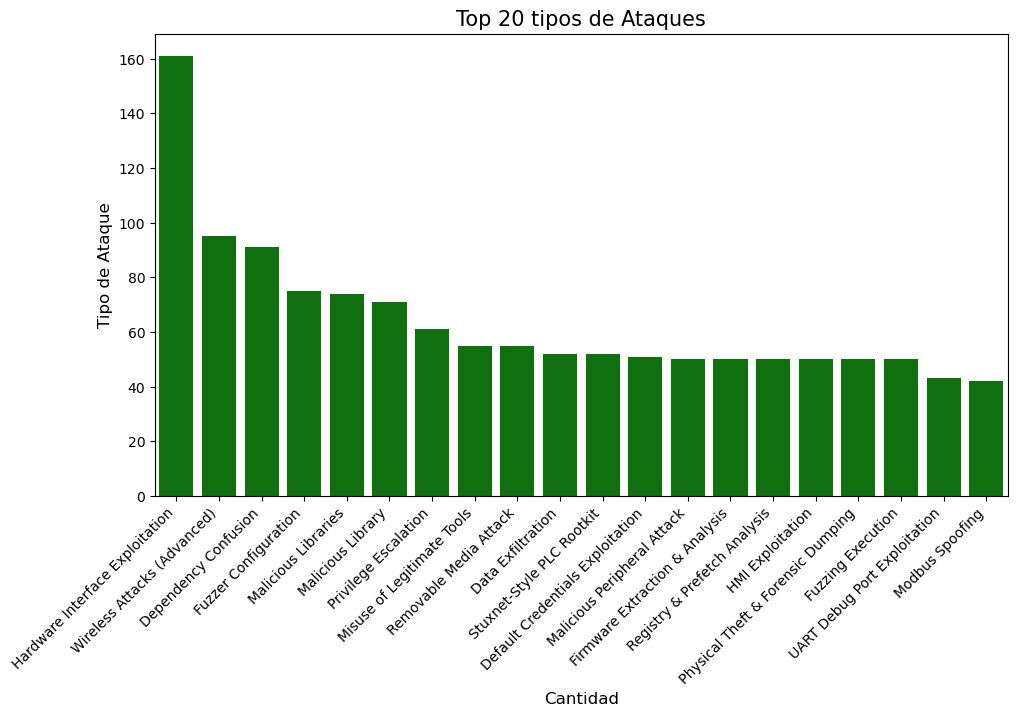

In [15]:
plt.figure(figsize=(11,6))
df_attack_type = df["Attack Type"].value_counts()
sns.countplot(x=df["Attack Type"], order=df_attack_type.index[:20], color='green')
plt.title('Top 20 tipos de Ataques',fontsize=15)
plt.xlabel('Cantidad',fontsize=12)
plt.ylabel('Tipo de Ataque', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

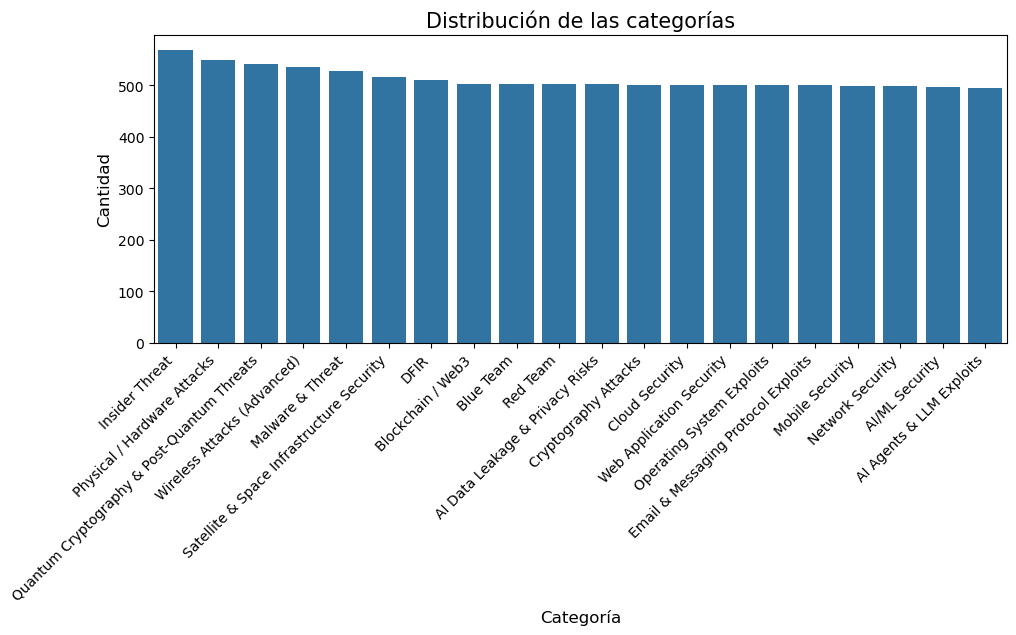

In [17]:
plt.figure(figsize=(11, 4))
df_category = df["Category"].value_counts()
sns.countplot(x=df["Category"], order=df_category.index[:20])
plt.title('Distribución de las categorías', fontsize=15)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [19]:
top_categories = df["Category"].value_counts().head(20).index
top_attacks = df["Attack Type"].value_counts().head(20).index

filtered_df = df[
    (df["Category"].isin(top_categories)) & 
    (df["Attack Type"].isin(top_attacks))
]

pd.crosstab(filtered_df["Category"], filtered_df["Attack Type"], margins=True)\
    .style.background_gradient(cmap="Blues")

Attack Type,Data Exfiltration,Default Credentials Exploitation,Dependency Confusion,Hardware Interface Exploitation,Misuse of Legitimate Tools,Privilege Escalation,Registry & Prefetch Analysis,Removable Media Attack,Wireless Attacks (Advanced),All
Category,,,,,,,,,,
Blue Team,8,0,0,0,0,3,50,0,0,61
Cloud Security,1,0,0,0,0,4,0,0,0,5
DFIR,0,0,0,0,0,1,0,0,0,1
Insider Threat,37,0,0,0,55,45,0,0,0,137
Mobile Security,1,0,1,0,0,0,0,0,0,2
Network Security,0,1,0,0,0,0,0,0,0,1
Operating System Exploits,0,0,0,0,0,1,0,0,0,1
Physical / Hardware Attacks,0,0,0,161,0,0,0,55,0,216
Quantum Cryptography & Post-Quantum Threats,0,0,0,0,0,0,0,0,95,95


Se observa una alta correlación entre "Category" y "Attack Type".

# Data Preparation
### Limpieza de Datos

Se identificaron valores nulos en múltiples variables como Vulnerability (18) y MITRE Technique (24).

- La columna Unnamed: 15 corresponde a una variable basura, por lo que será eliminada.<br>
- En 'Attack Steps ' se observa un espacio que será eliminado.
- Imputación de valores faltantes 

In [24]:
df.drop(columns=['Unnamed: 15'], inplace=True, errors='ignore')
df.columns = df.columns.str.strip()

X_features = ['Title', 'Scenario Description', 'Vulnerability', 'MITRE Technique']
df[X_features] = df[X_features].fillna('None')

Transformamos el texto a minúscula evitando la duplicidad de palabras.

In [27]:
df['X_features'] = (
    df['Title'] + " " + 
    df['Scenario Description'] + " " + 
    df['Vulnerability'] + " " + 
    df['MITRE Technique']
).str.lower()

Existe un **desbalanceo de clases**: algunos tipos de ataques cuentan con una sola ocurrencia, por lo que no podrán utilizarse tras la división del dataset. Por lo tanto, se considerarán clases válidas únicamente aquellas con al menos dos instancias.

In [30]:
counts = df['Attack Type'].value_counts()
clases_validas = counts[counts >= 2].index
df = df[df['Attack Type'].isin(clases_validas)].copy()

# Modelling

Determinamos la variable Target [x]: Attack Type<br>
Determinamos la variable Features [y]: Title, Scenario Description, Vulnerability y MITRE Technique

In [34]:
# Definimos las variables X e y  
X = df['X_features'].str.lower()
y = df['Attack Type']
print(f"Dataset post Data Cleaning: {df.shape[0]} registros.")

Dataset post Data Cleaning: 6159 registros.


Se realiza la división de datos: **Train 80%** / **Test 20%**

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# División de datos 
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Muestra de la proporción del conjunto de datos 80/20
print(f"Train: {len(X_train_raw)}")
print(f"Test: {len(X_test_raw)}")


Train: 4927
Test: 1232


Visualizaciones

Generando visualizaciones del Análisis Exploratorio...
TIP: En la ventana emergente, haz clic derecho para copiar, o usa el ícono del disquete para guardar.



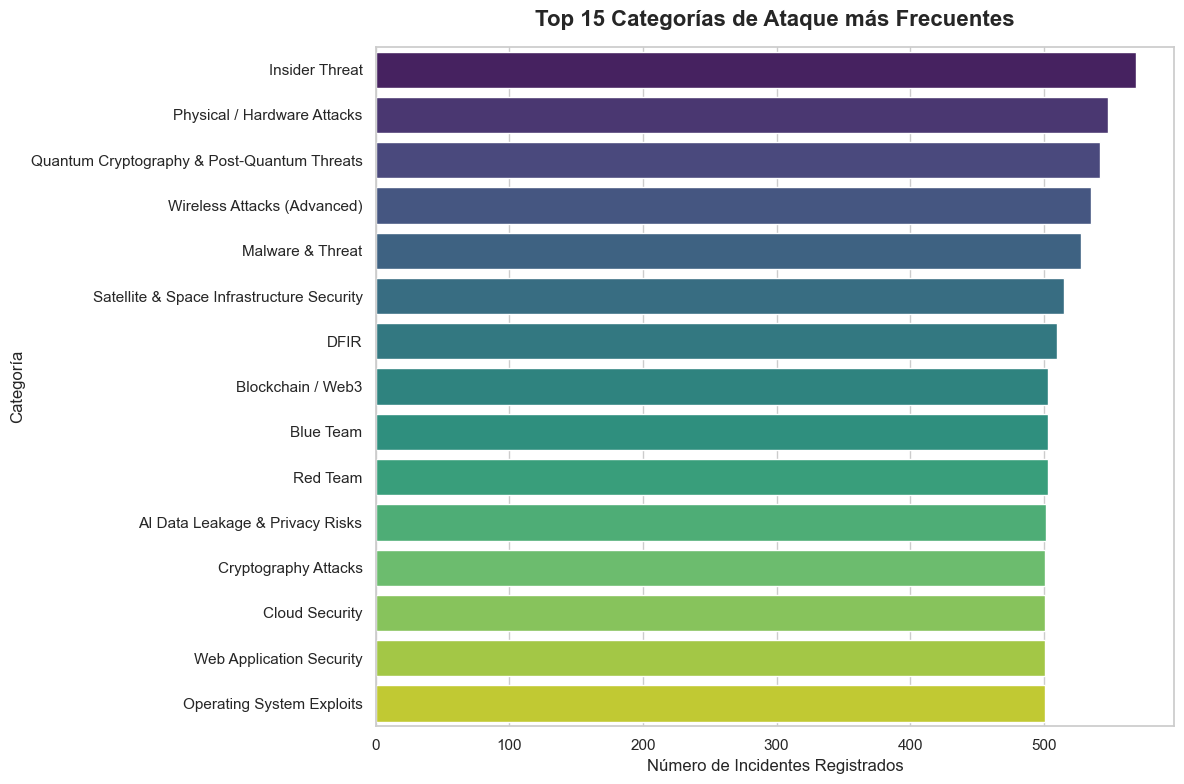

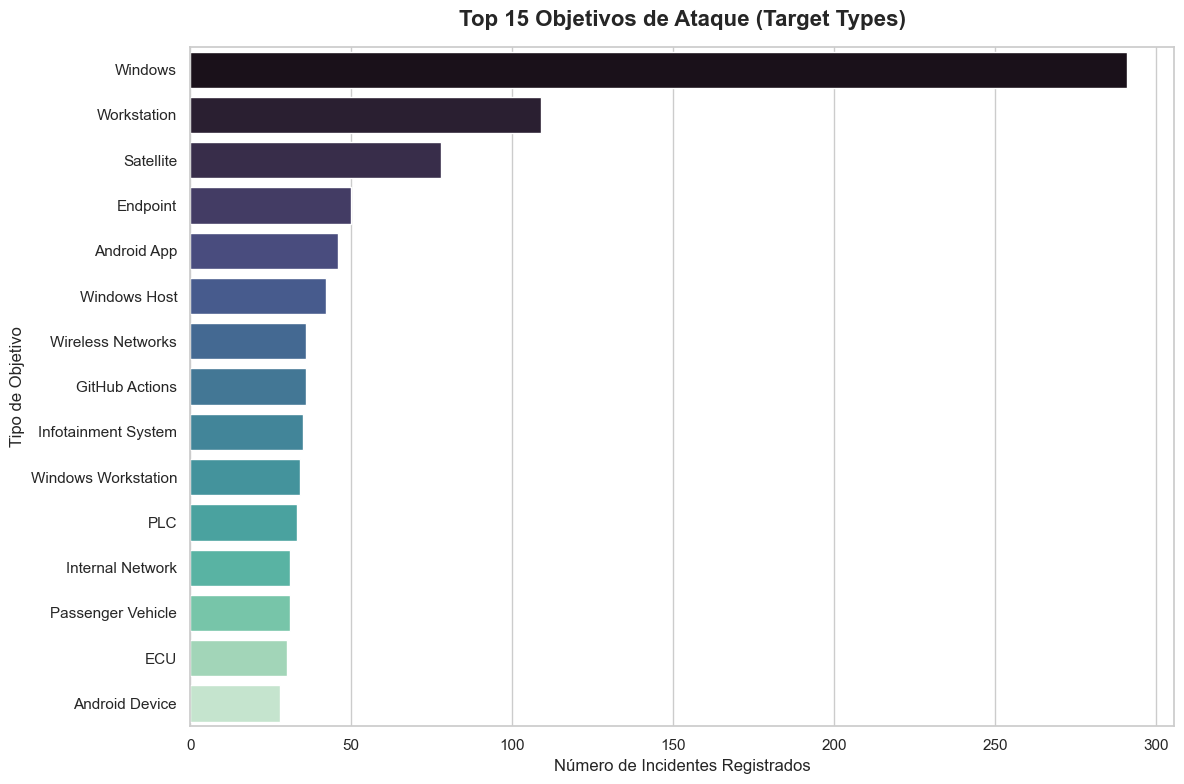

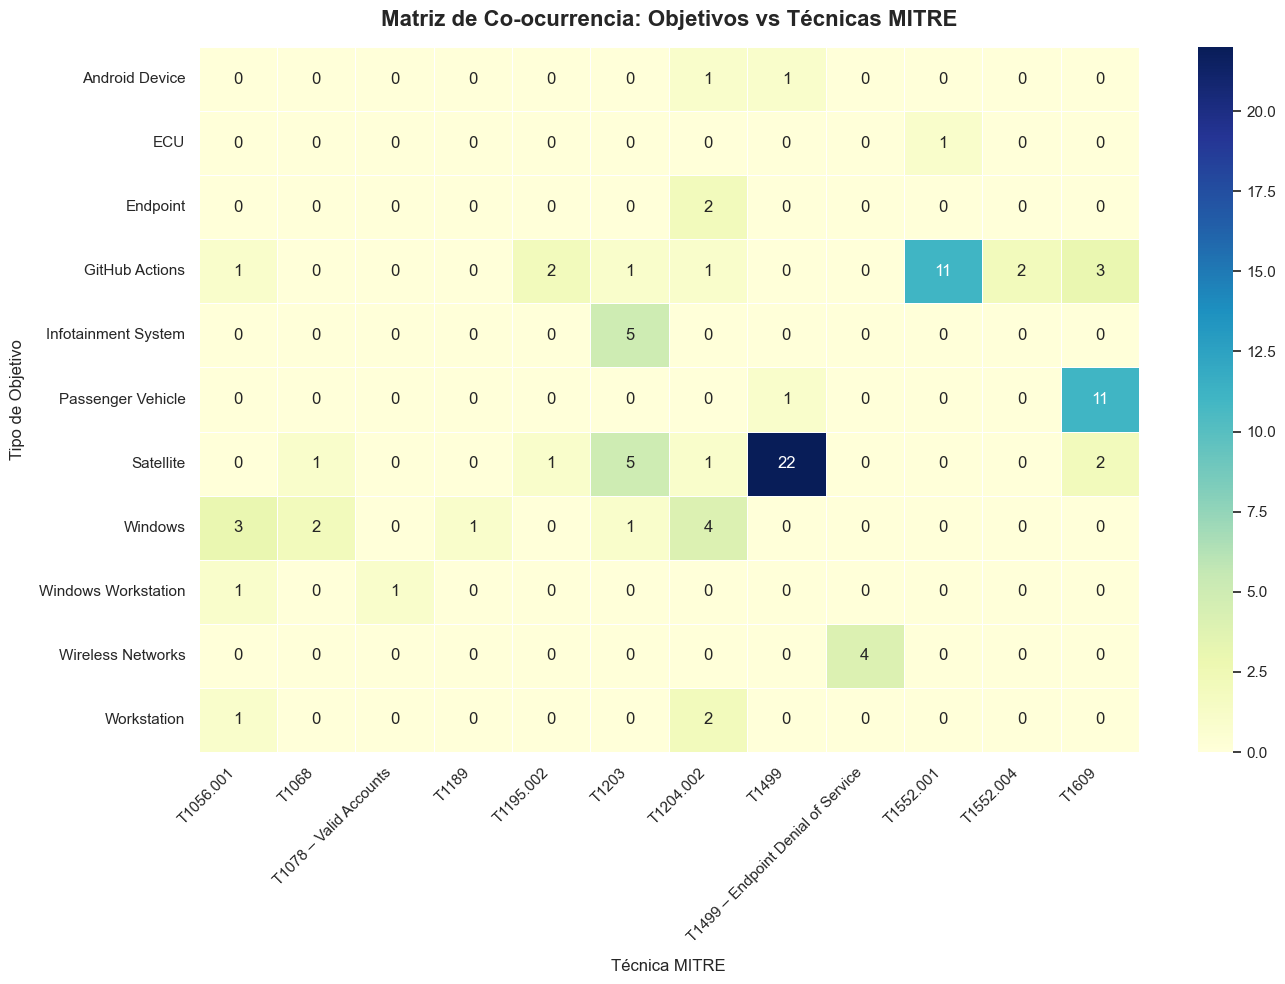

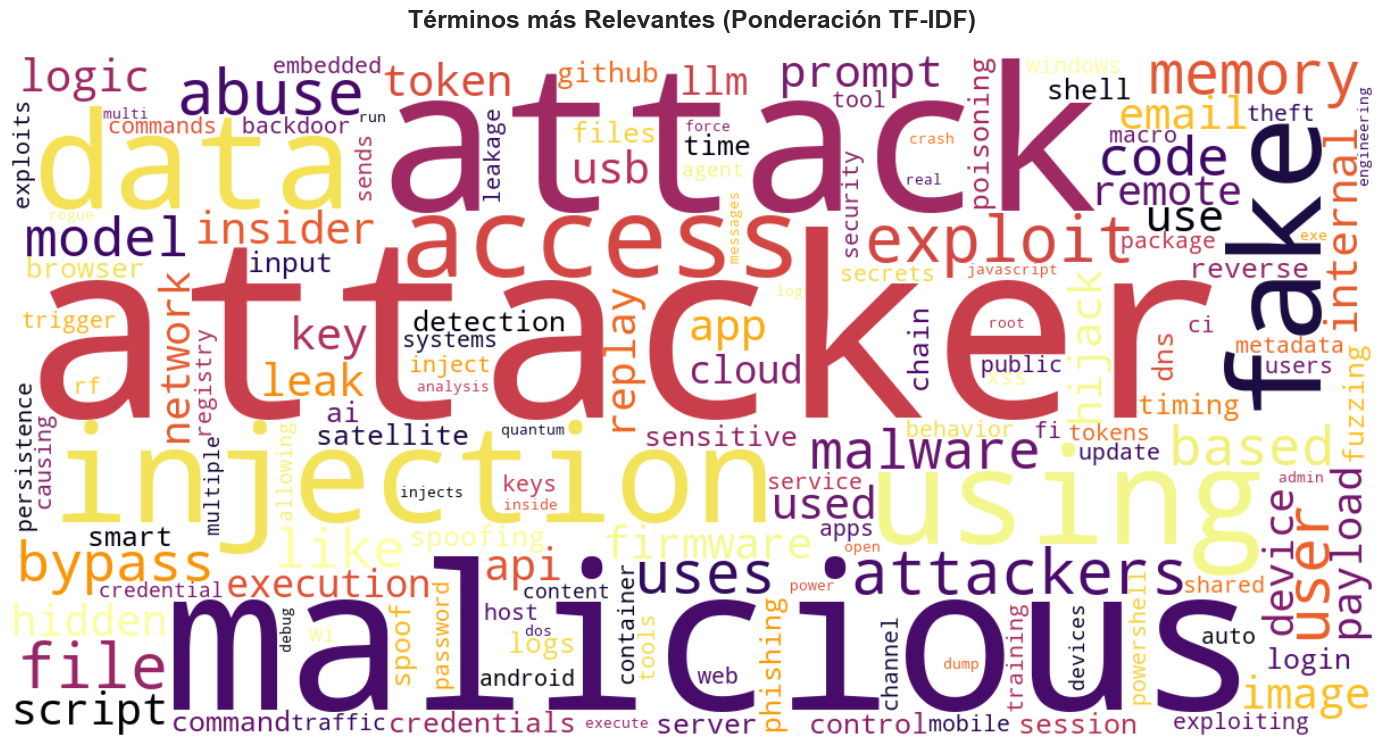

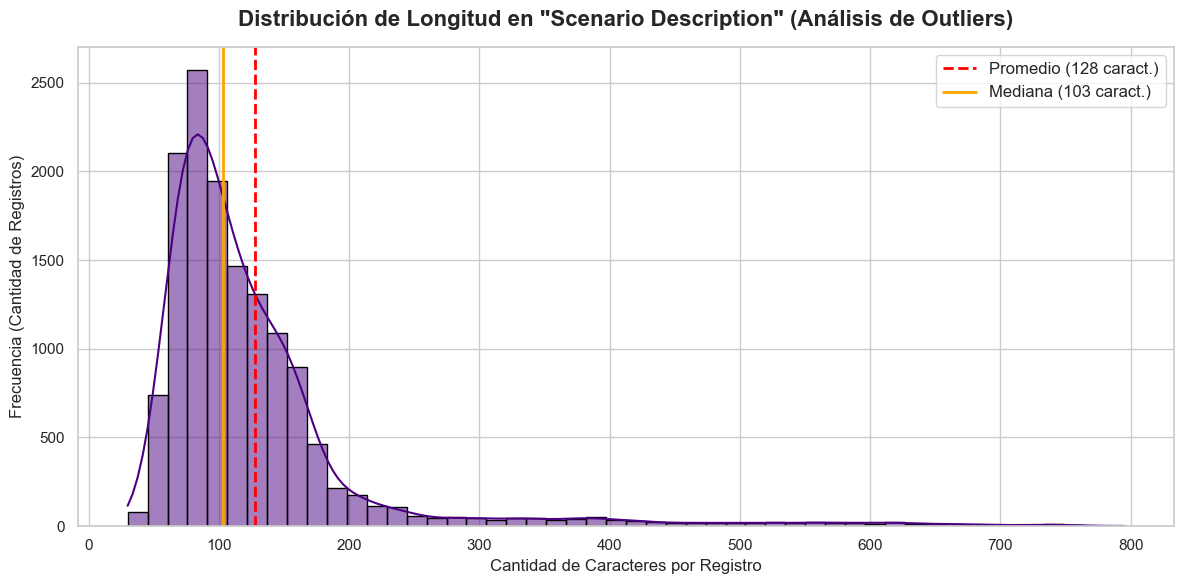


¡Proceso finalizado! Las 4 imágenes se han guardado con éxito.


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# ==============================================================================
# 0. CARGA DE DATOS Y CONFIGURACIÓN INICIAL
# ==============================================================================
df = pd.read_csv('Attack_Dataset.csv')

# Configuración visual estilo académico
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print("Generando visualizaciones del Análisis Exploratorio...")
print("TIP: En la ventana emergente, haz clic derecho para copiar, o usa el ícono del disquete para guardar.\n")

# ==============================================================================
# FIGURA 1: Distribución de Categorías (Bar Chart)
# ==============================================================================
plt.figure(figsize=(12, 8))
top_categories = df['Category'].value_counts().head(15)

# CORRECCIÓN APLICADA AQUÍ: Se agregó hue=top_categories.index y legend=False
sns.barplot(x=top_categories.values, y=top_categories.index, 
            hue=top_categories.index, palette="viridis", legend=False)

plt.title('Top 15 Categorías de Ataque más Frecuentes', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Número de Incidentes Registrados', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.tight_layout()

plt.savefig('figura1_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# FIGURA 2: Objetivos de ataque - Target Type (Bar Chart)
# ==============================================================================
plt.figure(figsize=(12, 8))
top_targets = df['Target Type'].value_counts().head(15)

# CORRECCIÓN APLICADA AQUÍ: Se agregó hue=top_targets.index y legend=False
sns.barplot(x=top_targets.values, y=top_targets.index, 
            hue=top_targets.index, palette="mako", legend=False)

plt.title('Top 15 Objetivos de Ataque (Target Types)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Número de Incidentes Registrados', fontsize=12)
plt.ylabel('Tipo de Objetivo', fontsize=12)
plt.tight_layout()

plt.savefig('figura2_objetivos.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# FIGURA 3: Mapa de Calor - Objetivos vs MITRE (Heatmap)
# ==============================================================================
plt.figure(figsize=(14, 10))
top_t = df['Target Type'].value_counts().head(15).index
top_m = df['MITRE Technique'].value_counts().head(15).index

df_heatmap = df[(df['Target Type'].isin(top_t)) & (df['MITRE Technique'].isin(top_m))]
co_occurrence = pd.crosstab(df_heatmap['Target Type'], df_heatmap['MITRE Technique'])

sns.heatmap(co_occurrence, cmap="YlGnBu", annot=True, fmt="d", linewidths=.5)
plt.title('Matriz de Co-ocurrencia: Objetivos vs Técnicas MITRE', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Técnica MITRE', fontsize=12, labelpad=10)
plt.ylabel('Tipo de Objetivo', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('figura3_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# FIGURA 4: Nube de Palabras ponderada por TF-IDF
# ==============================================================================
plt.figure(figsize=(14, 8))

cols_texto = ['Title', 'Scenario Description', 'Tags']
for col in cols_texto:
    df[col] = df[col].fillna('')

corpus = df['Title'] + " " + df['Scenario Description'] + " " + df['Tags']

vectorizer = TfidfVectorizer(stop_words='english', max_features=200)
tfidf_matrix = vectorizer.fit_transform(corpus)

sum_words = tfidf_matrix.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

wordcloud = WordCloud(width=1200, height=600, 
                      background_color='white', 
                      colormap='inferno',
                      max_words=150).generate_from_frequencies(dict(words_freq))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Términos más Relevantes (Ponderación TF-IDF)', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()

plt.savefig('figura4_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# FIGURA 5: Histograma de longitud de descripciones (Outliers Semánticos)
# ==============================================================================
plt.figure(figsize=(12, 6))

# 1. Limpiar nulos y calcular la longitud de cada descripción
df['Scenario Description'] = df['Scenario Description'].fillna('')
df['desc_length'] = df['Scenario Description'].apply(len)

# 2. Crear el histograma con curva de tendencia (KDE)
sns.histplot(df['desc_length'], bins=50, kde=True, color='indigo', edgecolor='black')

# 3. Calcular estadísticas clave para dibujarlas en el gráfico
promedio = df['desc_length'].mean()
mediana = df['desc_length'].median()

# Dibujar líneas para el Promedio y la Mediana
plt.axvline(promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio ({promedio:.0f} caract.)')
plt.axvline(mediana, color='orange', linestyle='solid', linewidth=2, label=f'Mediana ({mediana:.0f} caract.)')

# 4. Configuraciones visuales y etiquetas
plt.title('Distribución de Longitud en "Scenario Description" (Análisis de Outliers)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Cantidad de Caracteres por Registro', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Registros)', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()

# 5. Guardar y Mostrar
plt.savefig('figura5_histograma_longitud.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n¡Proceso finalizado! Las 4 imágenes se han guardado con éxito.")